# CMI and Markov length for repetition code

Calculating CMI with density matrices 

\begin{equation}

CMI = I(A:C|B) = S(AB) + S(BC) - S(ABC) - S(B),

\end{equation}

where $S(Q)$ is the von Neumann entropy of the $Q$ subsystem:

\begin{equation}

S(Q) = - tr ( \rho_{Q} \log \rho_Q ),

\end{equation}

with

\begin{equation}

\rho_{Q} = tr_{\bar{Q}} (\rho).

\end{equation}

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import math
from functools import reduce
import scienceplots

We start from defining the ground state as 

\begin{equation}
    \ket{\text{g.s.}} = \ket{0}^{\otimes N},
\end{equation}

and it's density matrix as:
\begin{equation}
    \rho_0 =\ket{\text{g.s.}}\bra{\text{g.s.}} = \ket{0}\bra{0}^{\otimes N}.
\end{equation}

In [3]:
# ============================================================
# Defining rho_0
# ============================================================

# -------------------------
# Tensor product helper
# -------------------------
def kron_power(v, N):
    """Compute v ⊗ v ⊗ ... ⊗ v (N times)"""
    return reduce(np.kron, [v] * N)

# -------------------------
# Basis states |0> and |1>
# -------------------------
ket_0 = np.array([1, 0])
ket_1 = np.array([0, 1])


# -------------------------
# Function computing rho_0 given the system size
# -------------------------

def rho_rep_code_function(N):
    """
    Computing rho_GHZ given the system size
    N: total number of qubits
    """

    # Build product states
    # |0...0> and |1...1>
    ket_0N = kron_power(ket_0, N)
    ket_1N = kron_power(ket_1, N)

    # GHZ state
    ket_gs = ket_0N
    # Density matrix
    output = np.outer(ket_gs, ket_gs.conj())
    return output


rho_gs = rho_rep_code_function(12)
print(rho_gs)
print("Density matrix shape:", rho_gs.shape)


[[1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Density matrix shape: (4096, 4096)


Subsequantly, we define the noise channel:

\begin{equation}

\mathcal{E}^i_p(\cdot) = (1-p)(\cdot) + pX_i(\cdot)X_i

\end{equation}

acting on every qubit.

In [4]:
# ============================================================
# Defining the noise channel
# ============================================================

# -------------------------
# Defining Pauli X matrix 
# -------------------------
Pauli_X= np.array([[0, 1],[1, 0]])

# -------------------------
# Defining identity matrix 
# -------------------------
I = np.eye(2)

# -------------------------
# Defining local operator
# -------------------------
def local_operator(op, i, N):
    """
    Build operator acting on i-th qubit (0-based index) in N-qubit system.
    """
    ops = [I] * N
    ops[i] = op
    return reduce(np.kron, ops)

# -------------------------
# Defining the bit flip channel
# -------------------------
def bit_flip_channel(rho, p, i, N):
    """ 
    Function implementing the application of the noise channel on qubit i. 
    Returns the matrix rho_p_i after the application of the noise on one qubit
    i - qubit number
    p - noise rate 
    N - total system size
    rho - total density matrix
    """
    X_i = local_operator(Pauli_X, i, N)
    return (1 - p) * rho + p * (X_i @ rho @ X_i)

# -------------------------
# Repeated application of bit flip chanell -> noise channel
# -------------------------
def noise_channel(rho_0, p, N):
    """ 
    Function implementing the noise channel on qubit all qubits. 
    Returns the matrix rho_p_i after the application of the noise on one qubit
    i - qubit number
    p - noise rate 
    N - total system size
    rho_0 - initial density matrix
    """
    rho = rho_0
    for i in range(N):
        rho = bit_flip_channel(rho, p, i, N)
    return rho 

Now, we will define functions to caluclate von Neuman entropies of the whole matrix and the reduced density matrices to subsequently calculate CMI. 

In [5]:
# ============================================================
# Functions to compute CMI
# ============================================================

# -------------------------
# Calculating von Neumann entropy
# -------------------------
def von_neumann_entropy(rho):
    """
    Compute von Neumann entropy S(rho) = -Tr(rho log rho) = -Sum (lamba log lamba), 
    where lambda's are eigenvalues of rho
    """
    eigvals = np.linalg.eigvalsh(rho)

    # remove zeros safely
    eigvals = eigvals[eigvals > 1e-12]

    S = -np.sum(eigvals * np.log2(eigvals))

    return S

# -------------------------
# Function to compute reduced density matrix by tracing out subsystems
# -------------------------
def partial_trace(rho, keep, N):
    """
    Partial trace over all qubits not listed in keep.

    rho:
        Full density matrix of shape (2^N, 2^N)

    keep:
        List of qubit indices to keep, using Python 0-based indexing.

    N:
        Total number of qubits.

    Returns:
        Reduced density matrix on the qubits in keep.
    """

    keep = sorted(keep)

    # Qubits to trace out
    trace_out = [q for q in range(N) if q not in keep]

    # Reshape rho into tensor form:
    # rho[i1, i2, ..., iN, j1, j2, ..., jN]
    rho_tensor = rho.reshape([2] * N + [2] * N)

    # Trace out qubits from largest index to smallest.
    # This avoids axis-shifting problems after each trace.
    current_N = N

    for q in sorted(trace_out, reverse=True):
        rho_tensor = np.trace(
            rho_tensor,
            axis1=q,
            axis2=q + current_N,
        )
        current_N -= 1

    dim_keep = 2 ** len(keep)

    return rho_tensor.reshape(dim_keep, dim_keep)

# -------------------------
#Function to compute CMI
# -------------------------
def CMI(p, rho_0, A, B, C, N):
    """
    Compute I(A:C|B) = S(AB) + S(BC) - S(B) - S(ABC).
    """

    rho = noise_channel(rho_0, p, N)

    AB = sorted(A + B)
    BC = sorted(B + C)
    ABC = sorted(A + B + C)

    S_AB = von_neumann_entropy(partial_trace(rho, AB, N))
    S_BC = von_neumann_entropy(partial_trace(rho, BC, N))
    S_B = von_neumann_entropy(partial_trace(rho, B, N))
    S_ABC = von_neumann_entropy(partial_trace(rho, ABC, N))

    return S_AB + S_BC - S_B - S_ABC

The first partition into the regions that we are interested in for 12 qubits is given by:

\begin{align}

&A = [0,1,2,3]\\

&B = [4,5,10,11]\\

&C = [6,7,8,9],

\end{align}

where we considered the indexing of qubits staring from 0 to match the Python syntax. Subsequently, we compute CMI for this region partition.

In [6]:
# ============================================================
# Computation of CMI
# ============================================================

# -------------------------
# Partition into subregions A,B,C
# -------------------------

A = [0,1,2,3]

B = [4,5,10,11]

C = [6,7,8,9]

# -------------------------
# Computing CMI for different noise rates
# -------------------------

#Array of different noise rates
p_array = np.linspace(0.001,0.999,40)

cmi_array = np.zeros(len(p_array))

for i in range(len(p_array)):
    cmi_array[i] = CMI(p_array[i],rho_gs,A=A,B=B,C=C,N=12)

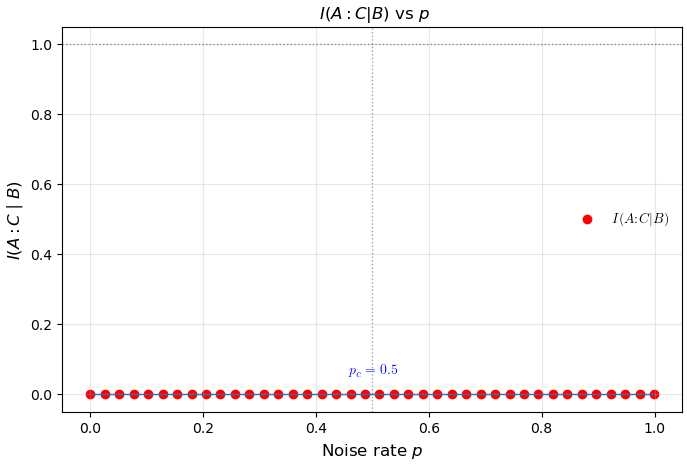

In [ ]:
# ============================================================
# Plot of the results of CMI vs noise rate p
# ============================================================


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(p_array, cmi_array,lw=1)
ax.scatter(p_array, cmi_array,color='red', label=r'$I(A{:}C|B)$')
ax.axhline(1.0, color='black', ls=':', alpha=0.4)
ax.axvline(0.5, color='darkblue', ls=':', alpha=0.4)
ax.set_xlabel(r'Noise rate $p$', fontsize=12)
ax.set_ylabel(r'$I(A{:}C \mid B)$ ', fontsize=12)
ax.set_title(r' $I(A{:}C|B)$ vs $p$', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.annotate(r'$p_c = 0.5$', xy=(0.5, 0.05), fontsize=10, color='blue',
            ha='center', va='bottom')
plt.style.use('science')
plt.savefig("New_plots/CMI_vs_p_rep_code.png", dpi=300)

plt.show()